In [34]:
import pymc as pm
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
import random
import math

In [2]:
df = pd.read_parquet('./../data/processed/bioasq_embeddings_subset.parquet')

In [ ]:
# df.sample(3)

In [ ]:
# df['label'].value_counts()

In [ ]:
# len(df)

In [3]:
X = np.stack(df['embedding'].values)
y = df['label'].values

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,         # 20% of data goes into test set
    random_state=42,       # For reproducibility
    stratify=y             # Ensures class distribution is preserved
)

Scale the features in the embeddings

In [27]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [35]:
p = 0.33
mu_intercept = math.log(p / (1 - p))
print(mu_intercept)

-0.7081850579244856


In [36]:
0.33/0.67

0.4925373134328358

In [41]:
with pm.Model() as logistic_model:
    # register data with the model
    X_shared = pm.Data("X_shared", X_train_scaled)
    y_shared = pm.Data("y_shared", y_train)
    
    # establish priors for coefficients
    coefficients = pm.Normal('coefficient', mu=0, sigma=1, shape=X_train_scaled.shape[1])
    intercept = pm.Normal('intercept', mu=mu_intercept, sigma=1)

    # linear combination (logits)
    logits = intercept + pm.math.dot(X_shared, coefficients)

    # define p = sigmoid(logits)
    p = pm.Deterministic("p", pm.math.sigmoid(logits))

    # likelihood (Bernoulli)
    likelihood = pm.Bernoulli('likelihood', logit_p=logits, observed=y_shared)

    # inference (sampling posterior)
    trace = pm.sample(1000, tune=1000, target_accept=0.9)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [coefficient, intercept]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 13 seconds.
There were 3000 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [ ]:
# logistic_model

In [42]:
p

p ~ Deterministic(f(coefficient, intercept))

Make predictions

In [38]:
with logistic_model:
    posterior_predictions = pm.sample_posterior_predictive(trace, 
                                                           var_names=['coefficient', 'intercept'])

    pp = posterior_predictions.posterior_predictive

    coefs = pp['coefficient'].values
    ints = pp['intercept'].values

    n_chains, n_draws, n_feats = coefs.shape
    coefs_flat = coefs.reshape(n_chains * n_draws, n_feats)    # (n_samples, features)
    ints_flat  = ints.reshape(n_chains * n_draws)   

    logits = ints_flat[:, None] + coefs_flat @ X_test_scaled.T
    
    probabilities = 1 / (1 + np.exp(-logits))

Sampling: [coefficient, intercept]


Output()

In [30]:
credible_interval = np.percentile(probabilities, [2.5, 97.5])
mean_probability = np.mean(probabilities)

In [31]:
print(f"Relevance probability: {np.mean(probabilities):.2f}")
print(f"95% credible interval: [{np.percentile(probabilities, 2.5):.2f}, {np.percentile(probabilities, 97.5):.2f}]")

Relevance probability: 0.50
95% credible interval: [0.00, 1.00]


Plot distribution for one prediction

In [32]:
probabilities.shape[1]

42

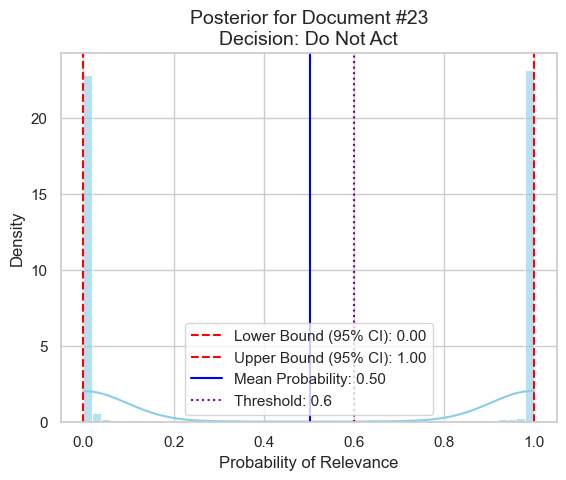

In [40]:
# randomly select a single document
doc_idx = random.randrange(probabilities.shape[1])

probs_doc = probabilities[:, doc_idx]

# Calculate mean and 95% credible interval
mean_prob = probs_doc.mean()
lower_bound, upper_bound = np.percentile(probs_doc, [2.5, 97.5])

# Decision based on threshold
threshold = 0.6
decision = "Act" if lower_bound > threshold else "Do Not Act"
decision_color = "green" if decision == "Act" else "red"

# Plotting using seaborn
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(probs_doc, bins=50, kde=True, stat="density", color='skyblue', alpha=0.6)
plt.axvline(lower_bound, color='red', linestyle='--', label=f'Lower Bound (95% CI): {lower_bound:.2f}')
plt.axvline(upper_bound, color='red', linestyle='--', label=f'Upper Bound (95% CI): {upper_bound:.2f}')
plt.axvline(mean_prob, color='blue', linestyle='-', label=f'Mean Probability: {mean_prob:.2f}')
plt.axvline(threshold, color='purple', linestyle=':', label=f'Threshold: {threshold}')

plt.title(f"Posterior for Document #{doc_idx}\nDecision: {decision}", fontsize=14)
plt.xlabel("Probability of Relevance", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend()
plt.show()


In [43]:
ppc = pm.sample_posterior_predictive(
    trace,
    var_names=["p"],
    return_inferencedata=False
)

TypeError: No model on context stack.

In [ ]:
probs_doc = ppc["p"][:, i]

In [12]:
type(probabilities)

numpy.ndarray

In [ ]:
probabilities